## Load data

In [ ]:
# ── Colab bootstrap: only runs if we're actually in Colab ──
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, subprocess
    from pathlib import Path

    REPO_DIR = Path("/content/cuhk-x")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/greentree327/cuhk-x.git", str(REPO_DIR)], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "origin", "master"], check=True)
    os.chdir(REPO_DIR)   # persists for the rest of the notebook — matches %cd

    subprocess.run(["pip", "install", "-q", "huggingface_hub"], check=True)

    # real token, entered securely — never hardcode a real token in a shared notebook
    import getpass
    os.environ["HF_TOKEN"] = getpass.getpass("Enter your HuggingFace read token: ")

    import sys
    sys.path.insert(0, str(REPO_DIR / "src"))
    from config import Config
    from data_bootstrap import ensure_dataset_available

    ensure_dataset_available(Config())   # no-op if already downloaded; otherwise fetches + extracts
    print("Colab data bootstrap complete.")


In [1]:
import sys, time
from pathlib import Path
from collections import defaultdict

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent  # in case the notebook is run from a subdirectory
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)

ROOT = Path.cwd()
if not (ROOT / "CUHK-X_Small_Model_Track").exists():
    ROOT = ROOT.parent

DATA_ROOT = (ROOT / "CUHK-X_Small_Model_Track" / "Small-Model-Track" / "Training"
             / "data" / "HAR_extracted" / "HAR" / "data")

"""
DATA_ROOT/
  <modality>/              e.g. Depth_Color, IR, Thermal, IMU, Radar, Skeleton
    <action>/               e.g. "10_Stir_drinks", "11_Peel_fruits"
      <user>/                e.g. "user4"
        <trial>/              e.g. "1-2-1"
          <files...>            the actual data files for that clip
"""

def parse_action_label(action_folder_name):
    """'0_Wash_face' -> 0, or None if it doesn't match."""
    parts = action_folder_name.split("_", 1)
    try:
        return int(parts[0])
    except (ValueError, IndexError):
        return None

clips = defaultdict(lambda: defaultdict(list))

""" 
clips = {
    ("10", "user4", "1-2-1"): {
        "IMU":         ["...file1...", "...file2..."],
        "Depth_Color": ["...file1...", "...file2..."],
        "Radar":       ["...file1...", ...],
    },
    ("11", "user5", "3-1-2"): {
        "IMU": [...],
        ...
    },
}

"""

for modality_dir in sorted(DATA_ROOT.iterdir()): # modality_dir = .../IMU
    if not modality_dir.is_dir():
        continue
    modality = modality_dir.name          # e.g. "IMU"

    for action_dir in sorted(modality_dir.iterdir()):
        action_id = parse_action_label(action_dir.name)   # "10_Stir_drinks" -> 10
        if action_id is None:
            continue

        for user_dir in sorted(action_dir.iterdir()):
            user = user_dir.name          # "user4"

            for trial_dir in sorted(user_dir.iterdir()):
                trial = trial_dir.name    # "1-2-1"
                files = sorted(str(f) for f in trial_dir.rglob("*") if f.is_file())
                # files = every file for this (modality, action, user, trial)
                key = (action_id, user, trial) # e.g. ( 10, "user4", "1-2-1")
                clips[key][modality] = files






In [2]:
# 1. Basic shape checks
print(type(clips))                     # <class 'collections.defaultdict'>
sample_key = next(iter(clips))
print(sample_key)                      # e.g. (10, 'user4', '1-2-1')
print(type(clips[sample_key]))         # <class 'collections.defaultdict'>
print(clips[sample_key])               # {'IMU': [...], 'Depth_Color': [...], ...}

# 2. Confirm the key is really a 3-tuple (action_id, user, trial)
assert len(sample_key) == 3
action_id, user, trial = sample_key
print(type(action_id), type(user), type(trial))   # int, str, str

# 3. Confirm the values are dicts of {modality: list of file paths}
for modality, files in clips[sample_key].items():
    print(modality, "->", len(files), "files, e.g.", files[0] if files else None)

# 4. Sanity-count: how many clips, how many total modality entries
print("total clips:", len(clips))
print("avg modalities per clip:", sum(len(v) for v in clips.values()) / len(clips))

# 5. Confirm no clip has more than 6 modalities (Depth_Color, IR, Thermal, IMU, Radar, Skeleton)
assert all(len(v) <= 6 for v in clips.values())

# 6. Spot-check a specific known clip if you know one exists on disk
print(clips.get((10, "user4", "1-2-1")))


<class 'collections.defaultdict'>
(0, 'user16', '1-1-1')
<class 'collections.defaultdict'>
defaultdict(<class 'list'>, {'Depth_Color': ['c:\\Users\\user\\Desktop\\CUHK_X\\CUHK-X_Small_Model_Track\\Small-Model-Track\\Training\\data\\HAR_extracted\\HAR\\data\\Depth_Color\\0_Wash_face\\user16\\1-1-1\\Depth_2025-06-10_10-43-49.016_00000151_Color.png', 'c:\\Users\\user\\Desktop\\CUHK_X\\CUHK-X_Small_Model_Track\\Small-Model-Track\\Training\\data\\HAR_extracted\\HAR\\data\\Depth_Color\\0_Wash_face\\user16\\1-1-1\\Depth_2025-06-10_10-43-49.116_00000152_Color.png', 'c:\\Users\\user\\Desktop\\CUHK_X\\CUHK-X_Small_Model_Track\\Small-Model-Track\\Training\\data\\HAR_extracted\\HAR\\data\\Depth_Color\\0_Wash_face\\user16\\1-1-1\\Depth_2025-06-10_10-43-49.216_00000153_Color.png', 'c:\\Users\\user\\Desktop\\CUHK_X\\CUHK-X_Small_Model_Track\\Small-Model-Track\\Training\\data\\HAR_extracted\\HAR\\data\\Depth_Color\\0_Wash_face\\user16\\1-1-1\\Depth_2025-06-10_10-43-49.316_00000154_Color.png', 'c:\\Use

In [3]:
from collections import Counter

action_counts = Counter(k[0] for k in clips.keys())
print(f"{len(action_counts)} distinct actions found")
for action_id, count in sorted(action_counts.items()):
    print(action_id, count)


40 distinct actions found
0 44
1 51
2 57
3 41
4 75
5 57
6 122
7 155
8 97
9 133
10 120
11 106
12 63
13 56
14 35
15 54
16 24
17 87
18 39
19 43
20 96
21 82
22 59
23 78
24 48
25 12
26 40
27 41
28 37
29 77
30 44
31 88
32 94
33 39
34 147
35 27
36 365
37 72
38 74
39 57


## Load Pretrained Resnet-18

In [4]:
import torchvision.models as models

weights = models.ResNet18_Weights.IMAGENET1K_V1
resnet18 = models.resnet18(weights=weights)
preprocess = weights.transforms()


In [5]:
print(resnet18)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
%pip install torchinfo


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from torchinfo import summary
summary(resnet18, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [8]:
print(preprocess)


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [9]:
from PIL import Image

img = Image.open(r"c:\\Users\\user\\Desktop\\CUHK_X\\CUHK-X_Small_Model_Track\\Small-Model-Track\\Training\\data\\HAR_extracted\\HAR\\data\\Depth_Color\\0_Wash_face\\user16\\1-1-1\\Depth_2025-06-10_10-43-49.016_00000151_Color.png")
print(img.mode, img.size)   # e.g. "RGB", (640, 480)

x = preprocess(img)         # PIL Image -> normalized tensor
print(x.shape)              # should be torch.Size([3, 224, 224])


RGB (640, 480)
torch.Size([3, 224, 224])


### View transformation

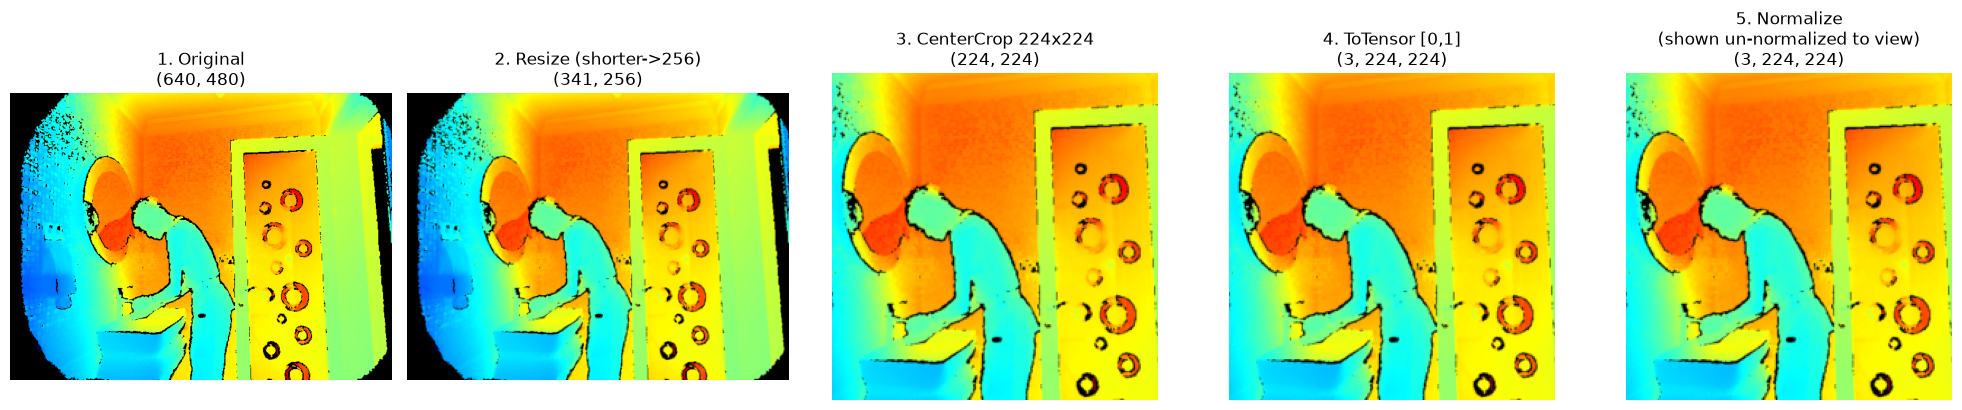

Manual pipeline matches weights.transforms(): True


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms

# Step 1: original
step1_original = img

# Step 2: resize shorter side to 256
step2_resize = transforms.Resize(256)(step1_original)

# Step 3: center crop to 224x224
step3_crop = transforms.CenterCrop(224)(step2_resize)

# Step 4: to tensor (scales [0,255] uint8 -> [0.0, 1.0] float, reorders to C,H,W)
step4_tensor = transforms.ToTensor()(step3_crop)

# Step 5: normalize with ImageNet mean/std
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
step5_normalized = (step4_tensor - mean) / std

# --- Display ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(step1_original)
axes[0].set_title(f"1. Original\n{step1_original.size}")

axes[1].imshow(step2_resize)
axes[1].set_title(f"2. Resize (shorter->256)\n{step2_resize.size}")

axes[2].imshow(step3_crop)
axes[2].set_title(f"3. CenterCrop 224x224\n{step3_crop.size}")

axes[3].imshow(step4_tensor.permute(1, 2, 0).numpy())
axes[3].set_title(f"4. ToTensor [0,1]\n{tuple(step4_tensor.shape)}")

# step5 has values outside [0,1] now (can go negative), so un-normalize just to VIEW it
step5_viewable = (step5_normalized * std + mean).clamp(0, 1)
axes[4].imshow(step5_viewable.permute(1, 2, 0).numpy())
axes[4].set_title(f"5. Normalize\n(shown un-normalized to view)\n{tuple(step5_normalized.shape)}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Sanity check: this whole manual pipeline should match preprocess(img) from weights.transforms()
x_via_preprocess = preprocess(step1_original)
print("Manual pipeline matches weights.transforms():", torch.allclose(step5_normalized, x_via_preprocess, atol=1e-5))


### Option 1: Load the first frame of the clip

In [11]:
first_frames = {}
for key, modalities in clips.items():
    depth_files = modalities.get("Depth_Color")
    if depth_files:
        first_frames[key] = sorted(depth_files)[0]   # first frame by filename (timestamp-sorted)

print(len(first_frames), "clips with a first Depth_Color frame")
sample_key = next(iter(first_frames))
print(sample_key, "->", first_frames[sample_key])


2931 clips with a first Depth_Color frame
(0, 'user16', '1-1-1') -> c:\Users\user\Desktop\CUHK_X\CUHK-X_Small_Model_Track\Small-Model-Track\Training\data\HAR_extracted\HAR\data\Depth_Color\0_Wash_face\user16\1-1-1\Depth_2025-06-10_10-43-49.016_00000151_Color.png


### Option 1.1 Transfer learning of Resnet-18

In [12]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedGroupKFold
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 0. Independent copy — resnet18 itself is NEVER modified from here on ──
resnet18_01 = copy.deepcopy(resnet18)

# ── 1. Freeze all layers of THE COPY, then replace + unfreeze only fc ──
for param in resnet18_01.parameters():
    param.requires_grad = False

num_classes = 40
resnet18_01.fc = nn.Linear(resnet18_01.fc.in_features, num_classes)   # fresh layer, requires_grad=True by default
fc_weight_before_fresh = resnet18_01.fc.weight.detach().clone()        # snapshot the NEW fc's init values

resnet18_01 = resnet18_01.to(device)

# ── 2. Dataset (unchanged) ──
class FirstFrameDataset(Dataset):
    def __init__(self, first_frames, transform):
        self.items = list(first_frames.items())
        self.transform = transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        key, path = self.items[idx]
        action_id = key[0]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        return x, action_id

dataset = FirstFrameDataset(first_frames, preprocess)

# ── 3. Stratified group split (unchanged) ──
keys = [key for key, path in dataset.items]
labels_arr = [key[0] for key in keys]
groups_arr = [key[1] for key in keys]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(X=keys, y=labels_arr, groups=groups_arr))

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

train_users = {groups_arr[i] for i in train_idx}
val_users = {groups_arr[i] for i in val_idx}
print("user overlap between train/val:", train_users & val_users)
print(f"train: {len(train_idx)} clips, {len(train_users)} users")
print(f"val:   {len(val_idx)} clips, {len(val_users)} users")

# ── 4. Sanity check: every non-fc PARAMETER frozen (this includes BatchNorm weight/bias — see explanation below) ──
for name, param in resnet18_01.named_parameters():
    if not name.startswith("fc."):
        assert not param.requires_grad, f"{name} is NOT frozen!"
print("confirmed: every non-fc parameter (including all BatchNorm weight/bias) has requires_grad=False")

# ── 5. Train only the fc layer of resnet18_01 ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18_01.fc.parameters(), lr=1e-3)

def freeze_bn(module):
    """Force BatchNorm layers into eval mode so running stats stop drifting,
    even though the rest of the model is in .train() mode for the fc layer."""
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

num_epochs = 20
for epoch in range(num_epochs):
    resnet18_01.train()
    # freeze_bn(resnet18_01)     # re-apply every epoch — .train() flips BN back on otherwise
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet18_01(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    resnet18_01.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet18_01(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"epoch {epoch+1}/{num_epochs}  loss={total_loss/total:.4f}  "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

# ── 6. Compare EVERY layer: pristine resnet18 vs trained resnet18_01 ──
print("\n=== Every parameter (conv, fc excluded — different shape) ===")
for (name0, p0), (name1, p1) in zip(resnet18.named_parameters(), resnet18_01.named_parameters()):
    assert name0 == name1
    if name0.startswith("fc."):
        continue   # original fc is (1000,512), new fc is (40,512) — not comparable, checked separately
    same = torch.equal(p0.detach().cpu(), p1.detach().cpu())
    print(f"{name0:40s} unchanged={same}")

print("\n=== BatchNorm running stats — NOT in named_parameters(), checked separately ===")
for (name0, m0), (name1, m1) in zip(resnet18.named_modules(), resnet18_01.named_modules()):
    if isinstance(m0, nn.BatchNorm2d):
        mean_same = torch.equal(m0.running_mean.cpu(), m1.running_mean.cpu())
        var_same  = torch.equal(m0.running_var.cpu(),  m1.running_var.cpu())
        print(f"{name0:40s} running_mean unchanged={mean_same}  running_var unchanged={var_same}")

print("\n=== FC layer (the only intended trainable part) ===")
fc_weight_after = resnet18_01.fc.weight.detach().clone().cpu()
print("fc changed:", not torch.equal(fc_weight_before_fresh.cpu(), fc_weight_after))


user overlap between train/val: set()
train: 2419 clips, 15 users
val:   512 clips, 3 users
confirmed: every non-fc parameter (including all BatchNorm weight/bias) has requires_grad=False
epoch 1/20  loss=3.3873  train_acc=0.134  val_acc=0.148
epoch 2/20  loss=2.8657  train_acc=0.204  val_acc=0.191
epoch 3/20  loss=2.6239  train_acc=0.268  val_acc=0.221
epoch 4/20  loss=2.4327  train_acc=0.316  val_acc=0.197
epoch 5/20  loss=2.2946  train_acc=0.350  val_acc=0.205
epoch 6/20  loss=2.1867  train_acc=0.359  val_acc=0.211
epoch 7/20  loss=2.0624  train_acc=0.399  val_acc=0.258
epoch 8/20  loss=1.9893  train_acc=0.427  val_acc=0.238
epoch 9/20  loss=1.8897  train_acc=0.468  val_acc=0.254
epoch 10/20  loss=1.8279  train_acc=0.489  val_acc=0.217
epoch 11/20  loss=1.7645  train_acc=0.511  val_acc=0.246
epoch 12/20  loss=1.7203  train_acc=0.510  val_acc=0.234
epoch 13/20  loss=1.6678  train_acc=0.523  val_acc=0.234
epoch 14/20  loss=1.6216  train_acc=0.539  val_acc=0.248
epoch 15/20  loss=1.565

### Option 1.2 Transfer learning of Resnet-18 with freezing BatchNorm

In [13]:
""" 
Option 1.1.1: Transfer learning of ResNet-18 WITH freezing BatchNorm
(compare against the earlier run where freeze_bn() was NOT applied —
 that run's BatchNorm running_mean/running_var will show unchanged=False;
 this run should show unchanged=True for every one of them)
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedGroupKFold
from PIL import Image
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 0. Load a fresh, untouched pretrained ResNet-18 ──
resnet18_02 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# ── 1. Freeze all layers, then replace + unfreeze only the final fc layer ──
for param in resnet18_02.parameters():
    param.requires_grad = False

num_classes = 40
resnet18_02.fc = nn.Linear(resnet18_02.fc.in_features, num_classes)   # fresh layer, requires_grad=True by default

resnet18_02 = resnet18_02.to(device)

# ── Snapshot BEFORE training: EVERY parameter + EVERY BatchNorm's running stats ──
params_before = {name: p.detach().clone().cpu()
                  for name, p in resnet18_02.named_parameters()}
bn_stats_before = {name: (m.running_mean.detach().clone().cpu(), m.running_var.detach().clone().cpu())
                    for name, m in resnet18_02.named_modules() if isinstance(m, nn.BatchNorm2d)}
fc_weight_before = resnet18_02.fc.weight.detach().clone().cpu()

# ── 2. Dataset: first Depth_Color frame per clip -> (image, label) ──
class FirstFrameDataset(Dataset):
    def __init__(self, first_frames, transform):
        self.items = list(first_frames.items())   # [((action_id, user, trial), path), ...]
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        key, path = self.items[idx]
        action_id = key[0]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        return x, action_id

dataset = FirstFrameDataset(first_frames, preprocess)

# ── 3. Stratified group split: stratify by action_id, group by user ──
keys = [key for key, path in dataset.items]      # [(action_id, user, trial), ...]
labels_arr = [key[0] for key in keys]              # action_id per clip
groups_arr = [key[1] for key in keys]               # user per clip (the grouping key)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(X=keys, y=labels_arr, groups=groups_arr))

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

# Sanity check: confirm no user appears in both splits
train_users = {groups_arr[i] for i in train_idx}
val_users = {groups_arr[i] for i in val_idx}
print("user overlap between train/val:", train_users & val_users)   # should print: set()
print(f"train: {len(train_idx)} clips, {len(train_users)} users")
print(f"val:   {len(val_idx)} clips, {len(val_users)} users")

# ── Sanity check: every non-fc parameter is gradient-frozen (includes BatchNorm weight/bias) ──
for name, param in resnet18_02.named_parameters():
    if not name.startswith("fc."):
        assert not param.requires_grad, f"{name} is NOT frozen!"
print("confirmed: every non-fc parameter (including all BatchNorm weight/bias) has requires_grad=False")

def freeze_bn(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

# ── 4. Train only the fc layer ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18_02.fc.parameters(), lr=1e-3)  # only fc has requires_grad=True anyway

num_epochs = 20
for epoch in range(num_epochs):
    resnet18_02.train()
    freeze_bn(resnet18_02)     # <-- the fix: re-applied every epoch since .train() flips BN back on
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet18_02(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # validation
    resnet18_02.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet18_02(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"epoch {epoch+1}/{num_epochs}  loss={total_loss/total:.4f}  "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

# ── Snapshot AFTER training and compare — every parameter + every BatchNorm's running stats ──
print("\n=== Every parameter (fc excluded — trained on purpose) ===")
for name, p_after in resnet18_02.named_parameters():
    if name.startswith("fc."):
        continue
    same = torch.equal(params_before[name], p_after.detach().cpu())
    print(f"{name:40s} unchanged={same}")

print("\n=== BatchNorm running stats (the whole point of this experiment) ===")
for name, module in resnet18_02.named_modules():
    if isinstance(module, nn.BatchNorm2d):
        mean_before, var_before = bn_stats_before[name]
        mean_same = torch.equal(mean_before, module.running_mean.detach().cpu())
        var_same  = torch.equal(var_before,  module.running_var.detach().cpu())
        print(f"{name:40s} running_mean unchanged={mean_same}  running_var unchanged={var_same}")

print("\n=== FC layer (the only intended trainable part) ===")
fc_weight_after = resnet18_02.fc.weight.detach().clone().cpu()
print("fc changed:", not torch.equal(fc_weight_before, fc_weight_after))


user overlap between train/val: set()
train: 2419 clips, 15 users
val:   512 clips, 3 users
confirmed: every non-fc parameter (including all BatchNorm weight/bias) has requires_grad=False
epoch 1/20  loss=3.4520  train_acc=0.124  val_acc=0.117
epoch 2/20  loss=2.9622  train_acc=0.204  val_acc=0.150
epoch 3/20  loss=2.6973  train_acc=0.261  val_acc=0.146
epoch 4/20  loss=2.5365  train_acc=0.290  val_acc=0.189
epoch 5/20  loss=2.4304  train_acc=0.303  val_acc=0.172
epoch 6/20  loss=2.2940  train_acc=0.350  val_acc=0.166
epoch 7/20  loss=2.1857  train_acc=0.371  val_acc=0.195
epoch 8/20  loss=2.1335  train_acc=0.383  val_acc=0.211
epoch 9/20  loss=2.0564  train_acc=0.424  val_acc=0.178
epoch 10/20  loss=1.9752  train_acc=0.444  val_acc=0.199
epoch 11/20  loss=1.9210  train_acc=0.456  val_acc=0.225
epoch 12/20  loss=1.8648  train_acc=0.466  val_acc=0.221
epoch 13/20  loss=1.8221  train_acc=0.471  val_acc=0.211
epoch 14/20  loss=1.7728  train_acc=0.493  val_acc=0.215
epoch 15/20  loss=1.735

### Option 1.3 use augmented data to train

In [14]:
from torchvision import transforms

# ── Augmented pipeline: TRAIN ONLY ──
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),   # crop: random zoom window
    transforms.RandomRotation(15),                          # tilt: mild, ±15° — matches likely real variation
    transforms.RandomHorizontalFlip(p=0.5),                 # flip: safe if no class is handedness-specific
    transforms.ColorJitter(brightness=0.2, contrast=0.2),    # mild lighting robustness
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

# ── Deterministic pipeline: VAL ONLY — reuse your existing `preprocess` if it already does this ──
val_transform = preprocess   # keep validation exactly as it was — no randomness

# ── Two dataset instances, same underlying data, different transforms ──
train_dataset_full = FirstFrameDataset(first_frames, train_transform)
val_dataset_full    = FirstFrameDataset(first_frames, val_transform)

train_set = Subset(train_dataset_full, train_idx)   # same indices as before
val_set   = Subset(val_dataset_full, val_idx)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)


In [ ]:
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet18_aug = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet18_aug.parameters():
    param.requires_grad = False
resnet18_aug.fc = nn.Linear(resnet18_aug.fc.in_features, num_classes)
resnet18_aug = resnet18_aug.to(device)

def freeze_bn(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18_aug.fc.parameters(), lr=1e-3)

num_epochs = 20
for epoch in range(num_epochs):
    resnet18_aug.train()
    freeze_bn(resnet18_aug)
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet18_aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    resnet18_aug.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet18_aug(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"epoch {epoch+1}/{num_epochs}  loss={total_loss/total:.4f}  "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")


epoch 1/20  loss=3.5241  train_acc=0.109  val_acc=0.105
epoch 2/20  loss=3.1703  train_acc=0.158  val_acc=0.111
epoch 3/20  loss=3.0343  train_acc=0.179  val_acc=0.129
epoch 4/20  loss=2.9677  train_acc=0.186  val_acc=0.115
epoch 5/20  loss=2.8377  train_acc=0.206  val_acc=0.160
epoch 6/20  loss=2.8239  train_acc=0.196  val_acc=0.119
epoch 7/20  loss=2.7439  train_acc=0.218  val_acc=0.154
epoch 8/20  loss=2.6831  train_acc=0.232  val_acc=0.143
epoch 9/20  loss=2.6633  train_acc=0.231  val_acc=0.180
epoch 10/20  loss=2.6158  train_acc=0.240  val_acc=0.168
epoch 11/20  loss=2.5601  train_acc=0.267  val_acc=0.174
epoch 12/20  loss=2.5678  train_acc=0.248  val_acc=0.139
epoch 13/20  loss=2.5424  train_acc=0.260  val_acc=0.164
epoch 14/20  loss=2.5077  train_acc=0.275  val_acc=0.168
epoch 15/20  loss=2.5044  train_acc=0.277  val_acc=0.172


### Option 2: Get a feature vector over time, and Average/max pooling over time

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedGroupKFold
from PIL import Image
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 1. Pick T evenly-spaced frames per clip (handles clips shorter than T by repeating) ──
def sample_frame_paths(depth_files, n_frames=8):
    depth_files = sorted(depth_files)               # timestamp order, same convention as first_frames
    n = len(depth_files)
    if n == 0:
        return []
    idx = np.linspace(0, n - 1, n_frames).round().astype(int)
    idx = np.clip(idx, 0, n - 1)
    return [depth_files[i] for i in idx]

# ── 2. Dataset: returns a (T, C, H, W) stack of frames per clip, not just one image ──
class MultiFrameDataset(Dataset):
    def __init__(self, clips, transform, n_frames=8):
        self.transform = transform
        self.n_frames = n_frames
        self.items = []                              # [(key, [frame_path, ...T]), ...]
        for key, modalities in clips.items():
            depth_files = modalities.get("Depth_Color")
            if depth_files:
                self.items.append((key, sample_frame_paths(depth_files, n_frames)))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        key, frame_paths = self.items[idx]
        action_id = key[0]
        frames = [self.transform(Image.open(p).convert("RGB")) for p in frame_paths]
        x = torch.stack(frames, dim=0)                # (T, C, H, W)
        return x, action_id

# ── 3. Model: frozen ResNet backbone (fc replaced with Identity -> raw 512-d feature per frame),
#            mean/max pool across time, then a trainable Linear head ──
class TemporalPoolClassifier(nn.Module):
    def __init__(self, backbone, num_classes, feat_dim=512, pool="mean"):
        super().__init__()
        self.backbone = backbone                      # frozen; forward() returns (N, feat_dim)
        self.pool = pool
        self.head = nn.Linear(feat_dim, num_classes)   # the only trainable part

    def forward(self, x):                              # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        feats = self.backbone(x)                        # (B*T, feat_dim)
        feats = feats.view(B, T, -1)                     # (B, T, feat_dim)
        pooled = feats.mean(dim=1) if self.pool == "mean" else feats.max(dim=1).values
        return self.head(pooled)                          # (B, num_classes)

def freeze_bn(model):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

# ── 4. Build the frozen backbone ──
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in backbone.parameters():
    p.requires_grad = False
backbone.fc = nn.Identity()                             # forward() now returns the 512-d pooled feature directly
backbone = backbone.to(device)

num_classes = 40
model = TemporalPoolClassifier(backbone, num_classes=num_classes, pool="mean").to(device)

# ── 5. Dataset + stratified group split (same convention as your first-frame pipeline) ──
dataset = MultiFrameDataset(clips, preprocess, n_frames=8)

keys = [key for key, _ in dataset.items]
labels_arr = [key[0] for key in keys]
groups_arr = [key[1] for key in keys]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(X=keys, y=labels_arr, groups=groups_arr))

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

# batch_size lowered vs your single-frame pipeline: each item is now 8 frames, not 1 —
# effective images-per-batch = batch_size * n_frames, so this keeps GPU memory comparable
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)

train_users = {groups_arr[i] for i in train_idx}
val_users = {groups_arr[i] for i in val_idx}
print("user overlap between train/val:", train_users & val_users)
print(f"train: {len(train_idx)} clips, {len(train_users)} users")
print(f"val:   {len(val_idx)} clips, {len(val_users)} users")

# ── 6. Confirm the backbone is frozen ──
for name, param in model.backbone.named_parameters():
    assert not param.requires_grad, f"{name} is NOT frozen!"
print("confirmed: entire backbone has requires_grad=False")

# ── 7. Train only the head ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.head.parameters(), lr=1e-3)

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    freeze_bn(model.backbone)
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"epoch {epoch+1}/{num_epochs}  loss={total_loss/total:.4f}  "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")
